In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import imutils
from skimage import measure

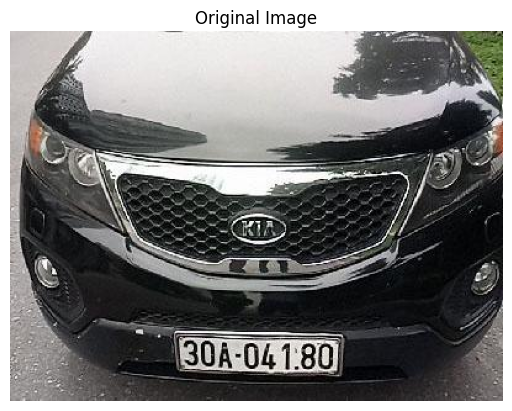

In [5]:
path = r'D:\Computer Vision Project\data\vietnamese car license plate\Tgmt_0054.png'

original = cv2.imread(path)
if original is None:
    raise FileNotFoundError(f"Image not found: {path}")

plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')
plt.show()

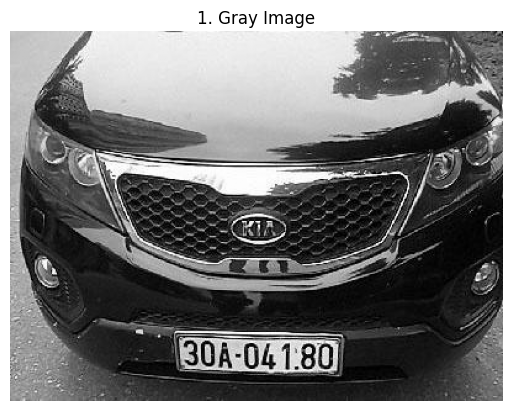

In [6]:
gray_image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

plt.imshow(gray_image, cmap='gray') 
plt.title('1. Gray Image')
plt.axis('off')
plt.show()

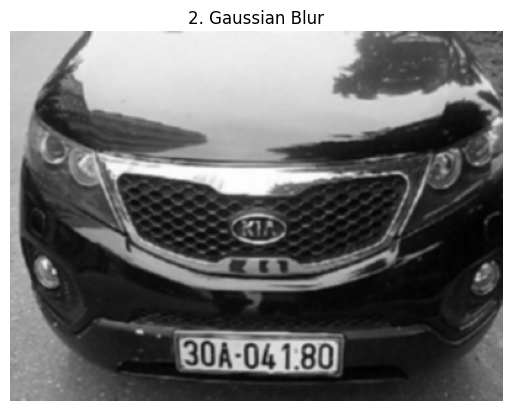

In [7]:
blur = cv2.GaussianBlur(gray_image.copy(), (5, 5), 0)

plt.imshow(blur, cmap='gray')
plt.title("2. Gaussian Blur")
plt.axis('off')
plt.show()

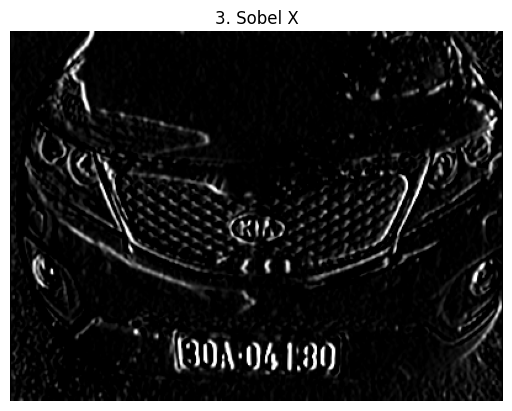

In [8]:
sobel = cv2.Sobel(blur, cv2.CV_8U, 1, 0, ksize=3)

plt.imshow(sobel, cmap='gray')
plt.title("3. Sobel X")
plt.axis('off')
plt.show()

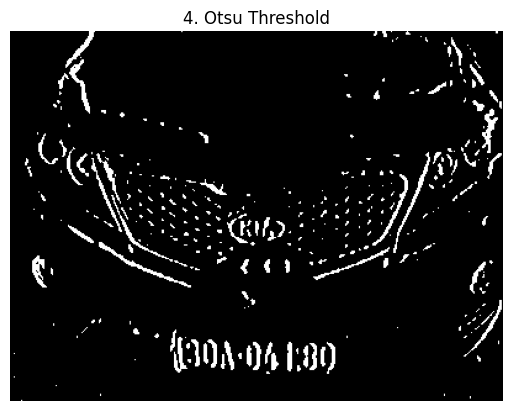

In [9]:
_, thresh = cv2.threshold(sobel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.imshow(thresh, cmap='gray')
plt.title("4. Otsu Threshold")
plt.axis('off')
plt.show()

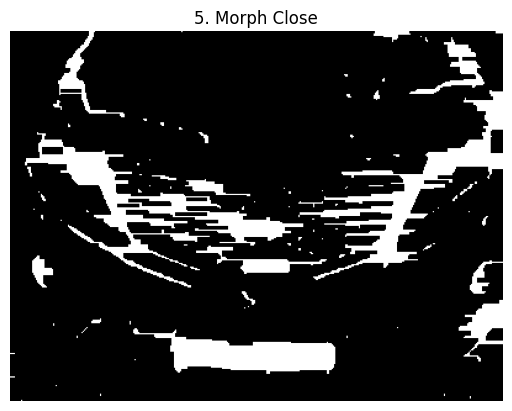

In [10]:
kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 3))
closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel_close)

plt.imshow(closed, cmap='gray')
plt.title("5. Morph Close")
plt.axis('off')
plt.show()

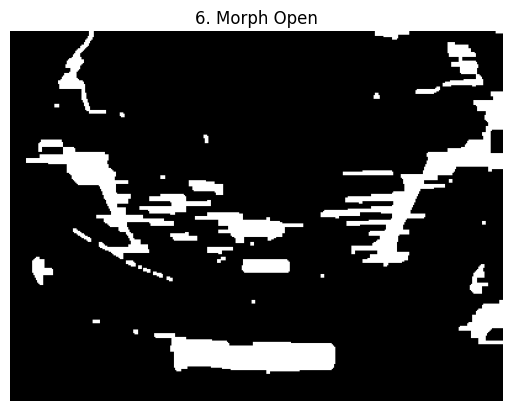

In [11]:
kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel_open)

plt.imshow(opened, cmap='gray')
plt.title("6. Morph Open")
plt.axis('off')
plt.show()

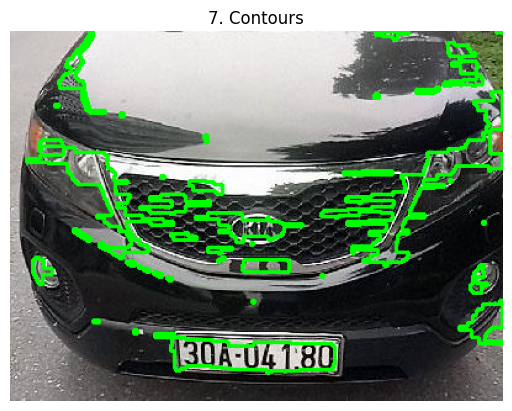

In [12]:
contours, _ = cv2.findContours(opened.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

contour_image = original.copy()
cv2.drawContours(contour_image, contours, -1, (0, 255, 0), 2) 

plt.imshow(cv2.cvtColor(contour_image, cv2.COLOR_BGR2RGB))
plt.title("7. Contours")
plt.axis('off')
plt.show()

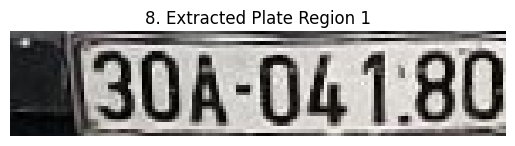

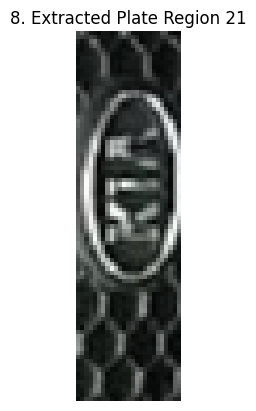

In [13]:
def rotate_and_crop(image, contour):
    rect = cv2.minAreaRect(contour)
    center, (w, h), angle = rect
    if w == 0 or h == 0:
        return None
    if angle < -45:
        angle += 90
    rot_mat = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, rot_mat, (image.shape[1], image.shape[0]))
    box = cv2.boxPoints(rect)
    box = np.intp(box)
    ones = np.ones((box.shape[0], 1))
    box_h = np.hstack([box, ones])
    rotated_box = (rot_mat @ box_h.T).T
    x, y, w, h = cv2.boundingRect(np.intp(rotated_box))
    return rotated[y:y + h, x:x + w]

original_copy = original.copy()
min_area = 1500
extracted_plates = []

for i, contour in enumerate(contours):
    x, y, w, h = cv2.boundingRect(contour)
    area = w * h
    aspect_ratio = w / float(h)
    
    if area > min_area and 2 <= aspect_ratio <= 8:
        cropped = rotate_and_crop(original_copy, contour)
        if cropped is None or cropped.size == 0:
            continue
        extracted_plates.append(cropped)
        
        plt.figure()
        plt.imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
        plt.title(f"8. Extracted Plate Region {i + 1}")
        plt.axis('off')
        plt.show()

if not extracted_plates:
    print("No plate candidates found with current thresholds.")

Plate has 8 characters detected.


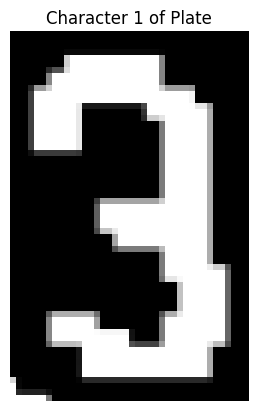

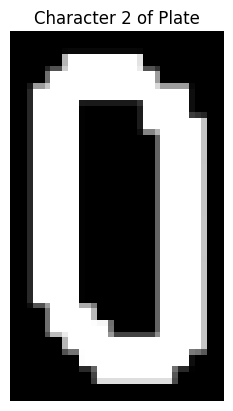

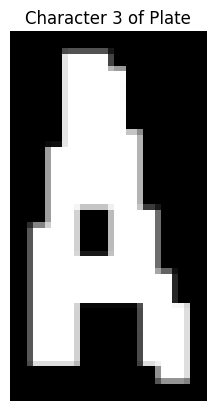

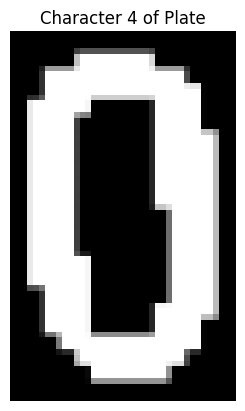

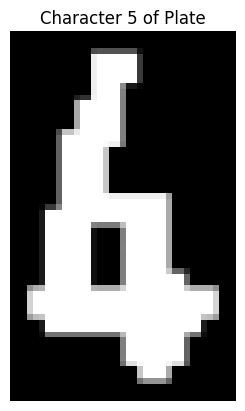

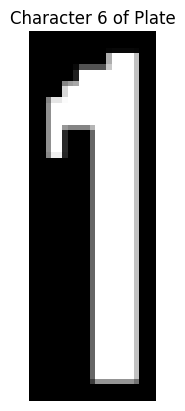

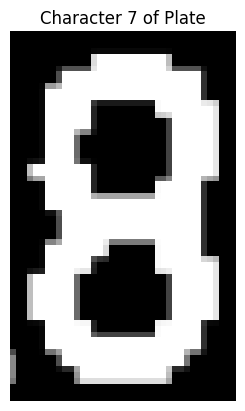

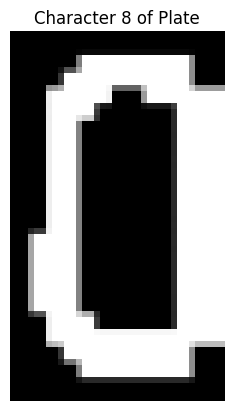

In [14]:
def segment_chars(plate_img, fixed_width=400):
    
    gray = cv2.cvtColor(plate_img, cv2.COLOR_BGR2GRAY)
    gray = cv2.bilateralFilter(gray, 9, 75, 75)
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY, 11, 2)
    thresh = cv2.bitwise_not(thresh)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2,2))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    plate_img = imutils.resize(plate_img, width=fixed_width)
    thresh = imutils.resize(thresh, width=fixed_width)
    bgr_thresh = cv2.cvtColor(thresh, cv2.COLOR_GRAY2BGR)

    labels = measure.label(thresh, background=0)
    charCandidates = np.zeros(thresh.shape, dtype='uint8')
    characters = []

    for label in np.unique(labels):
        if label == 0:
            continue
        labelMask = np.zeros(thresh.shape, dtype='uint8')
        labelMask[labels == label] = 255
        cnts = cv2.findContours(labelMask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cnts = cnts[1] if imutils.is_cv3() else cnts[0]
        if len(cnts) > 0:
            c = max(cnts, key=cv2.contourArea)
            (boxX, boxY, boxW, boxH) = cv2.boundingRect(c)
            aspectRatio = boxW / float(boxH)
            solidity = cv2.contourArea(c) / float(boxW * boxH)
            heightRatio = boxH / float(plate_img.shape[0])
            if aspectRatio < 2.0 and solidity > 0.05 and 0.1 < heightRatio < 0.98 and boxW > 3:
                hull = cv2.convexHull(c)
                cv2.drawContours(charCandidates, [hull], -1, 255, -1)

    contours, _ = cv2.findContours(charCandidates, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[0]) 
        addPixel = 4
        prev_x = -1
        for c in contours:
            (x, y, w, h) = cv2.boundingRect(c)
            if y > addPixel:
                y -= addPixel
            else:
                y = 0
            if x > addPixel:
                x -= addPixel
            else:
                x = 0
            if prev_x != -1 and x - prev_x > w * 2:
                continue
            char_img = bgr_thresh[y:y + h + addPixel*2, x:x + w + addPixel*2]
            characters.append(char_img)
            prev_x = x + w
        return characters if 5 <= len(characters) <= 9 else None
    return None


for i, plate_img in enumerate(extracted_plates):
    chars = segment_chars(plate_img, fixed_width=400)
    if chars is not None:
        print(f"Plate has {len(chars)} characters detected.")
        for j, cimg in enumerate(chars):
            plt.figure()
            plt.imshow(cv2.cvtColor(cimg, cv2.COLOR_BGR2RGB))
            plt.title(f"Character {j+1} of Plate")
            plt.axis('off')
            plt.show()


Plate 1 has 8 characters detected using VPP.


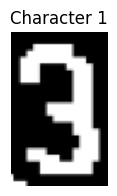

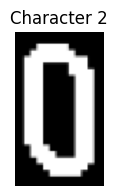

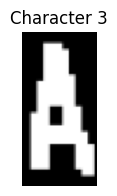

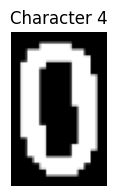

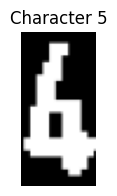

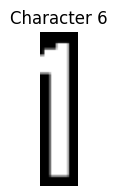

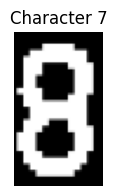

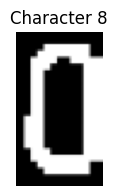

Plate 2: Không tìm thấy đủ số lượng ký tự (5-9) bằng VPP.


In [25]:
import cv2
import numpy as np
import imutils
import matplotlib.pyplot as plt

def segment_chars_pure_projection(plate_img, fixed_width=400):
    gray = cv2.cvtColor(plate_img, cv2.COLOR_BGR2GRAY)
    gray = cv2.bilateralFilter(gray, 9, 75, 75)
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 11, 2)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2,2))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    plate_img = imutils.resize(plate_img, width=fixed_width)
    thresh = imutils.resize(thresh, width=fixed_width)
    bgr_thresh = cv2.cvtColor(thresh, cv2.COLOR_GRAY2BGR)

    img_h, img_w = thresh.shape

    # 1. Tính toán Vertical Projection Profile (VPP) để cắt dọc (tìm x, w)
    vertical_projection = np.sum(thresh, axis=0) / 255
    col_threshold = np.max(vertical_projection) * 0.35 
    is_text_col = vertical_projection > col_threshold
    
    characters = []
    in_col_segment = False
    start_x = 0
    
    def process_column(start_x, end_x):
        # Bỏ qua các cột quá hẹp (nhiễu)
        if end_x - start_x < 5:
            return
            
        col_thresh = thresh[:, start_x:end_x]
        
        # 2. Tính toán Horizontal Projection Profile (HPP) trong nội bộ cột để cắt ngang (tìm y, h)
        horizontal_projection = np.sum(col_thresh, axis=1) / 255
        
        # Ngưỡng động cho HPP để tìm phần trên và dưới của ký tự
        row_threshold = np.max(horizontal_projection) * 0.15 
        is_text_row = horizontal_projection > row_threshold
        
        valid_rows = np.where(is_text_row)[0]
        if len(valid_rows) == 0:
            return
            
        # Lấy dòng có pixel chữ đầu tiên và cuối cùng
        start_y = valid_rows[0]
        end_y = valid_rows[-1]
        
        final_x = start_x
        final_y = start_y
        final_w = end_x - start_x
        final_h = end_y - start_y
        
        if final_h == 0:
            return
            
        aspect_ratio = final_w / float(final_h)
        height_ratio = final_h / float(img_h)
        
        # Điều kiện lọc kích thước
        if 0.1 < aspect_ratio < 1.5 and final_w > 5 and 0.25 < height_ratio < 0.95:
            addPixel = 4
            pad_x1 = max(0, final_x - addPixel)
            pad_x2 = min(img_w, final_x + final_w + addPixel)
            pad_y1 = max(0, final_y - addPixel)
            pad_y2 = min(img_h, final_y + final_h + addPixel)
            
            char_crop = bgr_thresh[pad_y1:pad_y2, pad_x1:pad_x2]
            characters.append((final_x, char_crop))

    # Quét qua VPP để tìm các khoảng văn bản
    for x, val in enumerate(is_text_col):
        if val and not in_col_segment:
            in_col_segment = True
            start_x = x
        elif not val and in_col_segment:
            in_col_segment = False
            process_column(start_x, x)
            
    if in_col_segment:
        process_column(start_x, len(is_text_col))

    if characters:
        # Sắp xếp từ trái qua phải
        sorted_chars = sorted(characters, key=lambda item: item[0])
        final_crops = [crop for _, crop in sorted_chars]
        
        if 5 <= len(final_crops) <= 9:
            return final_crops
    return None


# =======================================================
# Test và hiển thị bằng Matplotlib
# =======================================================
for i, plate_img in enumerate(extracted_plates):
    chars = segment_chars_vpp_clean(plate_img, fixed_width=400)
    
    if chars is not None:
        print(f"Plate {i+1} has {len(chars)} characters detected using VPP.")
        for j, cimg in enumerate(chars):
            plt.figure(figsize=(2,2)) # Chỉnh ảnh nhỏ lại một chút cho dễ nhìn
            plt.imshow(cv2.cvtColor(cimg, cv2.COLOR_BGR2RGB))
            plt.title(f"Character {j+1}")
            plt.axis('off')
            plt.show()
    else:
        print(f"Plate {i+1}: Không tìm thấy đủ số lượng ký tự (5-9) bằng VPP.")


In [16]:
import os
import sys
import logging

# Ensure src/ is on the import path for local modules
cwd = os.getcwd()
candidates = [os.path.join(cwd, "src"), os.path.join(os.path.abspath(os.path.join(cwd, "..")), "src")]
for p in candidates:
    if os.path.isdir(p) and p not in sys.path:
        sys.path.insert(0, p)

from character_recognition import CharacterRecognizer

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Tắt cảnh báo
logging.getLogger('tensorflow').setLevel(logging.ERROR)
logging.getLogger('absl').setLevel(logging.ERROR)

model_path = r'D:\Computer Vision Project\models\best_char_model.keras'
labels_path = r'D:\Computer Vision Project\models\labels_dict.json'
recognizer = CharacterRecognizer(model_path=model_path, labels_path=labels_path)

for i, plate_img in enumerate(extracted_plates):
    chars = segment_chars(plate_img, fixed_width=400)
    if chars is None:
        continue
    recognized_plate = recognizer.recognize_characters(chars, return_probs=False)
    print(f"Bien so nhan dien: {recognized_plate}")

KeyboardInterrupt: 